### General Imports:


In [1]:
import os
import gymnasium as gym
from stable_baselines3.ppo import PPO, MlpPolicy
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
from netsim.gym_basic.envs import RMSA_ENV
from netsim.netSimPy.common.allocators import sap_ff
from netsim.netSimPy import *
import numpy as np
import logging

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

logging.getLogger("tensorflow").setLevel(logging.FATAL)

/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# FILES AND DIRECTORIES:
__file__ = "[DAGGER] HEURISTIC_RF.ipynb"
absolutepath = os.path.abspath(__file__)
file_name = os.path.basename(os.path.abspath(__file__)).split(".")[0]
log_dir = f"./tmp/{file_name}/"
# SIMULATION PARAMS:
EPISODE_LENGTH = 1000
N_BLOCKS = 5
N_PATHS = 3
M_LAMBDA = 200000  # 300 Erlangs

networkPaths = "/Users/jbcedeno/Documents/projcts/multiband-gymnasium/networks/nsfnet"
network = Network(
    networkFileName=networkPaths + "/network.json",
    pathsFileName=networkPaths + "/routes.json",
    bitrateFilename=networkPaths + "/bitrates_c_bands.json",
)
generator = EventsGenerator(mLambda=M_LAMBDA)
sim_args = dict(eventsGenerator=generator, network=network)
simulator = NetworkSimulator(**sim_args)
# Building the environment:
env_args = dict(
    simulator=simulator,
    episode_length=EPISODE_LENGTH,
    j=N_BLOCKS,
    n_paths=N_PATHS,
    allocator=sap_ff(3),
)

env: RMSA_ENV = Monitor(gym.make("RMSA_ENV-v0", **env_args), log_dir)
eval_env: RMSA_ENV = Monitor(gym.make("RMSA_ENV-v0", **env_args), log_dir + "eval_env")

mArgs = dict(
    learning_rate=0.0005,
    gamma=0.9,
)
expert = PPO(MlpPolicy, env, verbose=0, seed=3, **mArgs)
train_model = expert.learn(total_timesteps=1)

# best_model_dir = f"./tmp/ACTION_RMSA_ENV/best_smooth_model"
# expert = PPO.load(best_model_dir)

/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


In [ ]:
from sklearn import ensemble
from netsim.explainable.common.dagger import Dagger
from netsim.explainable.common.beta import linear_beta
from netsim.netSimPy.common.heuristic_models import FirstFitModel


FEATURE_IDXS = [28, 41]
USE_FEATURE_SUBSET = True

n_rounds = 2
beta_func = linear_beta(1, 0, n_rounds)

if USE_FEATURE_SUBSET:
    selector = FunctionTransformer(
        lambda X: np.asarray(X)[:, FEATURE_IDXS], validate=False
    )
    student = Pipeline(
        [
            ("select", selector),
            (
                "clf",
                ensemble.RandomForestClassifier(
                    n_estimators=20,
                    max_depth=2,
                    criterion="entropy",
                ),
            ),
        ]
    )
else:
    student = ensemble.RandomForestClassifier(n_estimators=1, max_depth=2)

expert = FirstFitModel()

dagger_trainer = Dagger(expert, student, env, beta_func)
model = dagger_trainer.train(n_rounds, timesteps_by_round=10000, n_evaluations=100)

#
#

#
#

Starting round 1
Sampling new trajectories for round: {1} 
1.0 [[93  0  0]
 [ 0  5  0]
 [ 0  0  2]]
Starting round 2
Sampling new trajectories for round: 2 
Fitting student for round: 2 
1.0 [[88  0  0]
 [ 0  8  0]
 [ 0  0  4]]


### Mostrar grafo


In [8]:
# # Mostrar el grafo:
# tree_output_dir = f"./plots/{__file__}/decision_tree/"
# os.makedirs(tree_output_dir, exist_ok=True)

# rf_model = student.named_steps["clf"] if hasattr(student, "named_steps") else student
# feature_labels = (
#     FEATURE_IDXS if USE_FEATURE_SUBSET else list(range(rf_model.n_features_in_))
# )
# feature_names = [f"feature_{idx}" for idx in feature_labels]
# plt.figure(figsize=(8, 4))
# ensemble.plot_tree(rf_model, filled=True, rounded=True, feature_names=feature_names)
# plt.savefig(tree_output_dir + "decision_tree.png", bbox_inches="tight")
# plt.show()

### features importance


[0.79691697 0.20308303]


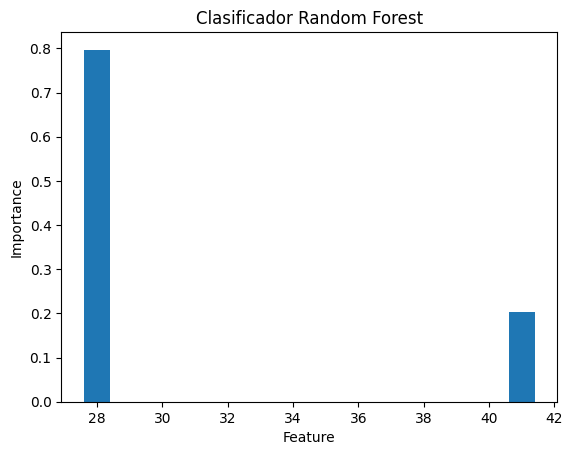

In [12]:
import pandas as pd

base_output_dir_features = f"./plots/{__file__}/features_importance_heuristic/"

output_dir = base_output_dir_features
os.makedirs(output_dir, exist_ok=True)


rf_model = student.named_steps["clf"] if hasattr(student, "named_steps") else student
importances_sk = rf_model.feature_importances_
feature_labels = (
    FEATURE_IDXS if USE_FEATURE_SUBSET else list(range(rf_model.n_features_in_))
)
importance = pd.DataFrame(importances_sk, index=feature_labels)
print(importances_sk)
plt.figure()
plt.bar(feature_labels, importances_sk)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title(f"Clasificador Random Forest")
plt.savefig(output_dir + "NSFNet.png")
plt.show()